# Проект спринта 28. Рекомендательная система для книжного сервиса

Вы - начинающий сотрудник книжного сервиса ReadMe. Его каталог пока небольшой: около пятисот книг, но платформа нашла свою аудиторию и постепенно растёт.

Главная страница сервиса - его витрина. Сейчас на ней всем пользователям показывают один и тот же блок «Популярное». Клиенты действительно читают популярные книги, но такие рекомендации работают недостаточно хорошо. Так, любители нон-фикшена видят в подборке самое популярное фэнтези, но, разумеется, не идут его читать. Продуктовая команда часто получает такой фидбэк: «Мне рекомендуют то, к чему я бы даже не притронулся!» Из-за этого конверсия с главной страницы в чтение расположенных на ней книг почти не растёт.

Ваша задача: собрать пайплайн рекомендательной модели и обоснованно выбрать модель на замену популярному списку. Каталог мал, поэтому двухуровневая архитектура с генерацией кандидатов здесь избыточна: скоринг всех книг считается за секунды.

Главный вопрос проекта: **какая модель рекомендаций работает лучше на небольшом каталоге и почему?**

Условия задачи:
 * Нужно составить список топ-K рекомендаций при `K = 10` для пользователей с тёплым стартом.
 * Релевантным считаем айтем, которому пользователь в тесте поставил оценку не ниже 4.
 * Модели, которые нужно построить, - popularity baseline, content-based, item-based CF и ALS
 * Метрики, которые нужно рассчитать, - precision@10, recall@10, MAP@10, NDCG@10 и coverage.

Данные в папке `datasets`:

- `ds_28_project_interactions.csv` - история взаимодействий, признаки `user_id`, `item_id`, `rating` (1–5), `timestamp`;
- `ds_28_project_items.csv` - каталог книг, признаки `item_id`, `title`, `author`, `description`, `category`, `year`;
- `ds_28_project_users.csv` - читатели, признаки `user_id`, `age_group`, `city`.

**Как работать с шаблоном.** В ячейках с `...` допишите недостающий код. То, что именно нужно сделать, написано в комментарии рядом с пропуском. Не меняйте названия ключевых переменных: они используются в следующих блоках. Ячейки с `assert` - это проверки вашего решения, их менять не нужно. После каждого блока отвечайте на вопросы из ячейки «Выводы по шагу», для ответа достаточно 2–3 предложений.

## Подготовка к работе: установка библиотек и настройка окружения

Подключаем библиотеки и задаём константы проекта.

Вам нужно только зафиксировать сиды `random` и `numpy`.

In [42]:
%pip install numpy pandas matplotlib scipy scikit-learn implicit ipython

In [43]:
import os

# Ограничиваем внутренние потоки BLAS: ALS из библиотеки implicit работает на CPU стабильнее и без предупреждений
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import random
from pathlib import Path

import implicit
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import OneHotEncoder, normalize


In [44]:
RANDOM_STATE = 42   # Сид воспроизводимости
K = 10              # Длина списка рекомендаций
REL_THRESHOLD = 4   # Порог релевантности: оценка >= 4
CUTOFF_VAL_Q = 0.70   # Временной порог разделения train и validation
CUTOFF_TEST_Q = 0.85  # Временной порог разделения validation и test

DATA_DIRS = [
    Path("/content/drive/MyDrive/datasets"),
    Path("/datasets"),
    Path("."),
]

def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(RANDOM_STATE)
print("Сид зафиксирован:", RANDOM_STATE)

Сид зафиксирован: 42


## Шаг 1. Загрузка данных и первичный осмотр

Загрузите три таблицы и проанализируйте их на типичные проблемы: типы данных, пропуски, дубликаты, корректность ключей.

In [45]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive монтирован")
except ImportError:
    print("Локальное использование")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive монтирован


In [46]:
def get_df(file_name, **read_csv_kwargs):
    for base in DATA_DIRS:
        path = base / file_name
        if path.exists():
            return pd.read_csv(path, sep=",", decimal=".", **read_csv_kwargs)

    raise FileNotFoundError(
        f"{file_name} not found in: {', '.join(str(d) for d in DATA_DIRS)}"
    )

In [47]:
interactions = get_df("ds_28_project_interactions.csv", parse_dates=["timestamp"])
items = get_df("ds_28_project_items.csv")
users = get_df("ds_28_project_users.csv")

print("interactions:", interactions.shape, "| items:", items.shape, "| users:", users.shape)
display(interactions.head())
display(items.head(3))
display(users.head(3))

interactions: (26240, 4) | items: (500, 6) | users: (1500, 3)


,user_id,item_id,rating,timestamp
0,268,61,4,2023-01-04 01:43:50
1,1240,219,5,2023-01-04 04:55:00
2,833,362,3,2023-01-04 13:14:37
3,1240,185,5,2023-01-04 23:22:12
4,268,447,4,2023-01-05 04:46:31


,item_id,title,author,description,category,year
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,"История о поиске себя, в которой каждый узнает...",янг-эдалт,2008.0
1,2,Harry Potter and the Sorcerer's Stone (Harry P...,J.K. Rowling,"История о избранном герое, которому предстоит ...",фэнтези,1997.0
2,3,"Twilight (Twilight, #1)",Stephenie Meyer,"История о избранном герое, которому предстоит ...",фэнтези,NaN


,user_id,age_group,city
0,1,18–25,Новосибирск
1,2,36–50,Казань
2,3,50+,Москва


In [48]:
for name, table in [("interactions", interactions), ("items", items), ("users", users)]:
    print(f"--- {name} ---")
    display(pd.DataFrame({
        "dtype": table.dtypes,
        "missing": table.isna().sum(),
        "unique": table.nunique(),
    }))

--- interactions ---


,dtype,missing,unique
user_id,int64,0,1500
item_id,int64,0,500
rating,int64,0,5
timestamp,datetime64[ns],0,26202


--- items ---


,dtype,missing,unique
item_id,int64,0,500
title,object,0,500
author,object,0,317
description,object,0,301
category,object,0,7
year,float64,20,124


--- users ---


,dtype,missing,unique
user_id,int64,0,1500
age_group,object,0,4
city,object,0,6


In [49]:
n_full_duplicates = interactions.duplicated().sum()
print("Полных дубликатов строк:", n_full_duplicates)

interactions = interactions.drop_duplicates().reset_index(drop=True)
print("После удаления:", interactions.shape)

# Проверяем, остались ли повторные пары «пользователь - айтем» (без учёта времени)
print("Повторных пар user-item:", interactions.duplicated(subset=["user_id", "item_id"]).sum())

Полных дубликатов строк: 30
После удаления: (26210, 4)
Повторных пар user-item: 0


In [50]:
print("Событий с неизвестным item_id:", (~interactions["item_id"].isin(items["item_id"])).sum())
print("Событий с неизвестным user_id:", (~interactions["user_id"].isin(users["user_id"])).sum())

Событий с неизвестным item_id: 0
Событий с неизвестным user_id: 0


In [51]:
print("Пропусков в year:", items["year"].isna().sum())

year_median = items["year"].median()
items["year"] = items["year"].fillna(year_median)
print(f"Пропуски заполнены медианой: {year_median:.0f}")

Пропусков в year: 20
Пропуски заполнены медианой: 1998


Нашлось 30 полных дубликатов - совпадают все поля, включая timestamp, так что это повторы записи одного события; удалил, чтобы не завышать популярность. Ключи чистые: 0 событий с неизвестными item_id и user_id. 20 пропусков в year заполнил медианой (1998) - терять книги из маленького каталога дороже, чем подставить значение в слабый признак.

## Шаг 2. EDA

Изучите свойства данных, от которых зависит моделирование: масштаб, заполненность матрицы взаимодействий, распределения событий и оценок.

In [52]:
n_users = interactions["user_id"].nunique()
n_items = interactions["item_id"].nunique()
n_events = len(interactions)
density = n_events / (n_users * n_items)

print("Пользователей:", n_users, "| Айтемов:", n_items, "| Взаимодействий:", n_events)
print(f"Заполненность матрицы взаимодействий: {density:.2%}")

Пользователей: 1500 | Айтемов: 500 | Взаимодействий: 26210
Заполненность матрицы взаимодействий: 3.49%


События на пользователя:
count    1500.0
mean       17.5
std         4.7
min         8.0
25%        14.0
50%        18.0
75%        22.0
max        24.0
dtype: float64

События на айтем:
count    500.0
mean      52.4
std       35.4
min        9.0
25%       29.0
50%       40.0
75%       65.2
max      258.0
dtype: float64


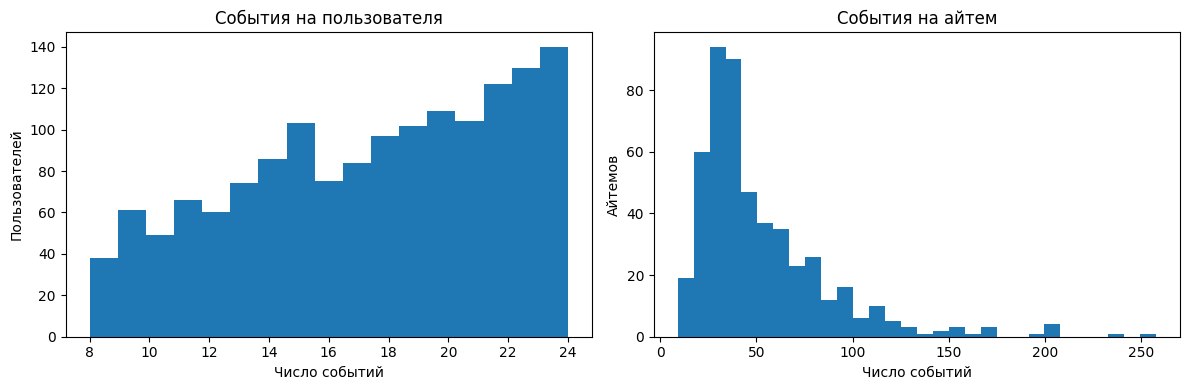

In [53]:
per_user = interactions.groupby("user_id").size()
per_item = interactions.groupby("item_id").size()

print("События на пользователя:")
print(per_user.describe().round(1))
print()
print("События на айтем:")
print(per_item.describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(per_user, bins=17)
axes[0].set_title("События на пользователя")
axes[0].set_xlabel("Число событий")
axes[0].set_ylabel("Пользователей")
axes[1].hist(per_item, bins=30)
axes[1].set_title("События на айтем")
axes[1].set_xlabel("Число событий")
axes[1].set_ylabel("Айтемов")
plt.tight_layout()
plt.show()

In [54]:
share_items_lt10 = (per_item < 10).mean()
top10_items = per_item.nlargest(max(1, round(len(per_item) * 0.1)))
share_top10_events = top10_items.sum() / n_events

print(f"Айтемов с менее чем 10 событиями: {share_items_lt10:.1%}")
print(f"Доля событий у топ-10% айтемов: {share_top10_events:.1%}")

Айтемов с менее чем 10 событиями: 0.2%
Доля событий у топ-10% айтемов: 25.5%


,share
rating,
1,0.031
2,0.071
3,0.244
4,0.324
5,0.331


Доля оценок >= 4: 65.5%


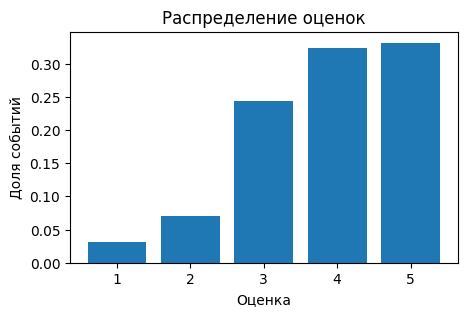

In [55]:
rating_distribution = interactions["rating"].value_counts(normalize=True).sort_index()
display(rating_distribution.round(3).rename("share").to_frame())

share_high = (interactions["rating"] >= REL_THRESHOLD).mean()
print(f"Доля оценок >= {REL_THRESHOLD}: {share_high:.1%}")

plt.figure(figsize=(5, 3))
plt.bar(rating_distribution.index.astype(str), rating_distribution.values)
plt.title("Распределение оценок")
plt.xlabel("Оценка")
plt.ylabel("Доля событий")
plt.show()

1500 пользователей, 500 книг, 26 210 событий, заполненность 3.49% - данные разрежены, вкус приходится обобщать по ~17 оценкам на человека. Настоящего длинного хвоста нет: топ-10% книг собрали лишь 25.5% событий, книг с менее чем 10 оценками - 0.2%, значит популярность здесь слабый сигнал, а поведенческим моделям хватает данных почти по всему каталогу. Фидбэк эксплицитный, 65.5% оценок ≥ 4, поэтому релевантность в тесте определяем по знаку оценки, а не по факту взаимодействия.

## Шаг 3. Временной сплит

Разделите события по времени: обучение должно происходить на самых ранних данных, валидация и проверка - на более поздних. Два порога-квантиля делят события на три части: `train` - для обучения всех моделей, `validation` - для подбора гиперпараметров ALS, `test` - для финального тестирования.

Каталог, история пользователей и вся статистика дальше строятся только по `train`.


In [56]:
cutoff_val = interactions["timestamp"].quantile(CUTOFF_VAL_Q)
cutoff_test = interactions["timestamp"].quantile(CUTOFF_TEST_Q)
train = interactions[interactions["timestamp"] < cutoff_val]
validation = interactions[(interactions["timestamp"] >= cutoff_val) & (interactions["timestamp"] < cutoff_test)]
test = interactions[interactions["timestamp"] >= cutoff_test]

print("Порог train|validation:", cutoff_val)
print("Порог validation|test:", cutoff_test)
print("train:", len(train), "| validation:", len(validation), "| test:", len(test))

Порог train|validation: 2024-04-12 04:34:05.500000
Порог validation|test: 2024-07-06 23:35:54.349999872
train: 18347 | validation: 3931 | test: 3932


In [57]:
item_ids = sorted(train["item_id"].unique())
id_to_row = {item_id: row for row, item_id in enumerate(item_ids)}
catalog = set(item_ids)
train_by_user = train.groupby("user_id")["item_id"].apply(list).to_dict()

print("Каталог train:", len(item_ids), "айтемов")
print("Пользователей с train-историей:", len(train_by_user))

Каталог train: 500 айтемов
Пользователей с train-историей: 1343


In [58]:
warm_users = set(train_by_user)
validation = validation[validation["user_id"].isin(warm_users)]
test = test[test["user_id"].isin(warm_users)]
test_users = test["user_id"].unique()

print("validation после warm-фильтрации:", len(validation))
print("test после warm-фильтрации:", len(test), "| warm-пользователей:", len(test_users))


validation после warm-фильтрации: 3188
test после warm-фильтрации: 1959 | warm-пользователей: 392


In [59]:
# Проверки честности разделения. Код уже готов, все проверки должны проходить без ошибок
assert train["timestamp"].max() < validation["timestamp"].min(), "train охватывает validation"
assert validation["timestamp"].max() < test["timestamp"].min(), "validation охватывает test"

overlap = pd.concat([
    train.merge(validation, on=["user_id", "item_id", "timestamp"]),
    train.merge(test, on=["user_id", "item_id", "timestamp"]),
    validation.merge(test, on=["user_id", "item_id", "timestamp"]),
])
assert overlap.empty, "Части выборок пересекаются по событиям"

print("Разделение честное: каждая выборка целиком в прошлом относительно следующей, пересечений нет.")


Разделение честное: каждая выборка целиком в прошлом относительно следующей, пересечений нет.


Сплит временной, потому что модель должна учиться на прошлом и проверяться на будущем - перемешивание дало бы утечку и завышенные метрики. Каталог и истории строим только по train, иначе фильтр «уже прочитанного» подсмотрит тест. assert-ы подтверждают, что каждая часть строго в прошлом относительно следующей. validation нужна один раз - для подбора факторов ALS.

## Шаг 4. Офлайн-метрики и единый формат предсказаний

Все модели проекта нужно оценить одной функцией. Для этого зафиксируем её логику: рекомендатель - это функция `recommender(user_id, n)`, которая возвращает список пар `(item_id, score)` по убыванию `score`; предсказания храним в едином формате `user_id`, `item_id`, `rank`, `score`, `model_id`, где `rank` начинается с 1.

In [60]:
def precision_at_k(recs, rel, k):
    """Доля релевантных айтемов среди первых k рекомендаций"""
    hits = sum(1 for item_id, _ in recs[:k] if item_id in rel)
    return hits / k


def recall_at_k(recs, rel, k):
    """Доля найденных релевантных от всех релевантных айтемов пользователя"""
    if not rel:
        return 0.0
    hits = sum(1 for item_id, _ in recs[:k] if item_id in rel)
    return hits / len(rel)


def map_at_k(recs, rel, k):
    """Average precision: точность в точках попаданий, усреднённая по релевантным"""
    if not rel:
        return 0.0
    hits, total = 0, 0.0
    for pos, (item_id, _) in enumerate(recs[:k], start=1):
        if item_id in rel:
            hits += 1
            total += hits / pos
    return total / min(len(rel), k)


def ndcg_at_k(recs, rel, k):
    """NDCG с бинарной релевантностью: DCG = сумма 1 / log2(позиция + 1)"""
    if not rel:
        return 0.0
    dcg = sum(1 / np.log2(pos + 1)
              for pos, (item_id, _) in enumerate(recs[:k], start=1) if item_id in rel)
    idcg = sum(1 / np.log2(pos + 1) for pos in range(1, min(len(rel), k) + 1))
    return dcg / idcg if idcg else 0.0

In [61]:
# Быстрая проверка метрик на пробном примере:
# Рекомендованы айтемы [1, 2, 3], релевантны {2, 4}
toy_recs = [(1, 0.9), (2, 0.8), (3, 0.7)]
toy_rel = {2, 4}

assert precision_at_k(toy_recs, toy_rel, 3) == 1 / 3
assert recall_at_k(toy_recs, toy_rel, 3) == 1 / 2
assert map_at_k(toy_recs, toy_rel, 3) == (1 / 2) / 2
assert abs(ndcg_at_k(toy_recs, toy_rel, 3) - (1 / np.log2(3)) / (1 + 1 / np.log2(3))) < 1e-9
print("Метрики на пробном примере посчитаны верно")

Метрики на пробном примере посчитаны верно


In [62]:
def positives_by_user(part):
    """user_id -> множество айтемов части данных с rating >= REL_THRESHOLD"""
    high = part[part["rating"] >= REL_THRESHOLD]
    return high.groupby("user_id")["item_id"].apply(set).to_dict()


pos_by_user = positives_by_user(test)
pos_by_user_val = positives_by_user(validation)


def make_ground_truth(positives):
    """Релевантные айтемы пользователя: rating >= порога, в каталоге train,
    не из его train-истории"""

    def ground_truth(user_id):
        seen = set(train_by_user.get(user_id, []))
        return {item_id for item_id in positives.get(user_id, set())
                if item_id in catalog and item_id not in seen}

    return ground_truth


ground_truth = make_ground_truth(pos_by_user)          # Финальная оценка на test
ground_truth_val = make_ground_truth(pos_by_user_val)  # Подбор гиперпараметров ALS

# Оцениваем только пользователей с непустым ground truth
eval_users = [user_id for user_id in test_users if ground_truth(user_id)]
val_users = [user_id for user_id in validation["user_id"].unique() if ground_truth_val(user_id)]
print("Пользователей в оценке (eval_users):", len(eval_users))
print("Пользователей в валидации (val_users):", len(val_users))


Пользователей в оценке (eval_users): 354
Пользователей в валидации (val_users): 600


In [63]:
def evaluate(recommender, users, k=K, truth=None):
    """Метрики по каждому пользователю с макро-усреднением + coverage"""
    truth = truth or ground_truth  # по умолчанию оцениваем на test
    acc = {name: [] for name in ["Precision@K", "Recall@K", "MAP@K", "NDCG@K"]}
    recommended_items = set()
    for user_id in users:
        rel = truth(user_id)
        recs = recommender(user_id, k)
        recommended_items.update(item_id for item_id, _ in recs)
        acc["Precision@K"].append(precision_at_k(recs, rel, k))
        acc["Recall@K"].append(recall_at_k(recs, rel, k))
        acc["MAP@K"].append(map_at_k(recs, rel, k))
        acc["NDCG@K"].append(ndcg_at_k(recs, rel, k))
    result = {name: float(np.mean(values)) for name, values in acc.items()}
    result["Coverage"] = len(recommended_items) / len(item_ids)  # доля каталога в выдаче
    return result


def predictions_frame(recommender, users, model_id, n=K):
    """Единый формат предсказаний: одна строка - одна рекомендация"""
    rows = []
    for user_id in users:
        for rank, (item_id, score) in enumerate(recommender(user_id, n), start=1):
            rows.append((user_id, item_id, rank, score, model_id))
    return pd.DataFrame(rows, columns=["user_id", "item_id", "rank", "score", "model_id"])


NDCG@10 - основная метрика: витрина короткая и порядок важнее всего. precision, recall и MAP дополняют картину, а coverage показывает, какую часть каталога система вообще способна показать. Усредняем по пользователям, чтобы активные читатели не перевесили остальных. В пуле 354 тёплых пользователя с непустым ground truth - он общий для всех моделей, иначе сравнивались бы не алгоритмы, а выборки.

## Шаг 5. Popularity baseline

Отправная точка сравнения - то, что сервис делает сейчас: рекомендует всем популярное. Популярность считаем по числу взаимодействий и только на train.

Вам нужно воспроизвести такую модель.

In [64]:
# Популярность по числу взаимодействий - только на train
pop = train["item_id"].value_counts()
top_pop = pop.index.tolist()

# Топ-5 популярных книг: это сейчас видят все пользователи сервиса
top5 = items.set_index("item_id").loc[pop.head(5).index, ["title", "category"]]
top5["events"] = pop.head(5).values
display(top5)


def recommend_popular(user_id, n=K):
    """Top-N популярных айтемов без тех, что пользователь уже видел в train"""
    seen = set(train_by_user.get(user_id, []))
    recs = []
    for item_id in top_pop:
        if item_id in seen:
            continue
        recs.append((item_id, float(pop[item_id])))
        if len(recs) >= n:
            break
    return recs

,title,category,events
item_id,,,
1,"The Hunger Games (The Hunger Games, #1)",янг-эдалт,187
61,The Girl on the Train,детектив,171
2,Harry Potter and the Sorcerer's Stone (Harry P...,фэнтези,152
3,"Twilight (Twilight, #1)",фэнтези,149
17,"Catching Fire (The Hunger Games, #2)",янг-эдалт,147


In [65]:
pred_pop = predictions_frame(recommend_popular, eval_users, "popularity")
display(pred_pop.head())

metrics_pop = evaluate(recommend_popular, eval_users)
print({name: round(value, 4) for name, value in metrics_pop.items()})

,user_id,item_id,rank,score,model_id
0,733,1,1,187.0,popularity
1,733,61,2,171.0,popularity
2,733,2,3,152.0,popularity
3,733,3,4,149.0,popularity
4,733,17,5,147.0,popularity


{'Precision@K': 0.0282, 'Recall@K': 0.0653, 'MAP@K': 0.0213, 'NDCG@K': 0.0463, 'Coverage': 0.028}


Baseline: precision 0.028, recall 0.065, MAP 0.021, NDCG 0.046 - меньше одного попадания на десять позиций. Coverage 0.028: на всех пользователей показано 14 книг из 500. Это и есть проблема из брифа - витрина одинаковая для всех, каталог не раскрывается.

## Шаг 6. Модель content-based

Подготовьте модель, которая порекомендует книги, похожие на те, что пользователю уже нравились. Используйте для этого признаки книг из каталога. Соберите айтем-профили из трёх типов признаков:

 * категорий, закодированных One-Hot Encoding;
 * объединённых текстовых названий и описаний книг, векторизованных с помощью TF-IDF;
 * года издания книги со значениями, нормализованными к диапазону [0, 1].

Профиль пользователя стройте только по книгам, которые получили в train оценку 4–5. Оценки ниже означают, что книга читателю не понравилась, и формировать по ним профиль пользователя ошибочно: так модель будет советовать заведомо неудачные книги. Профили отобранных книг взвесьте оценкой, просуммируйте и L2-нормируйте. Получите топ-10 по близости, сохраните предсказания, рассчитайте метрики.

In [66]:
# Берём признаки из каталога, но строки матрицы - в порядке item_ids (каталог train)
items_train = items.set_index("item_id").reindex(item_ids)

category_encoder = OneHotEncoder()
C = category_encoder.fit_transform(items_train[["category"]].fillna("unknown"))

text = (items_train["title"].fillna("") + " " + items_train["description"].fillna("")).values
T = TfidfVectorizer(max_features=300).fit_transform(text)

year = items_train["year"].fillna(year_median).values.reshape(-1, 1)
Y = (year - year.min()) / (year.max() - year.min())

item_mat = normalize(hstack([C, T, csr_matrix(Y) * 0.5]).tocsr())
print("матрица айтем-профилей:", item_mat.shape)

матрица айтем-профилей: (500, 308)


In [67]:
def build_user_profiles(train_df):
    """Профиль интересов: взвешенная по оценке сумма айтем-профилей книг
    с rating >= REL_THRESHOLD из train-истории, L2-нормировка"""
    # Оставьте только события с rating >= REL_THRESHOLD: интерес выражают высокие оценки
    positive = train_df[train_df["rating"] >= REL_THRESHOLD]
    profiles = {}
    for user_id, group in positive.groupby("user_id"):
        rows = [id_to_row[item_id] for item_id in group["item_id"]]
        weights = group["rating"].to_numpy(dtype=float)
        vector = np.asarray(item_mat[rows].T.dot(weights)).ravel()
        norm = np.linalg.norm(vector)
        if norm == 0:
            continue
        profiles[user_id] = vector / norm
    return profiles


user_profiles = build_user_profiles(train)
print("Профилей пользователей:", len(user_profiles))

Профилей пользователей: 1319


In [68]:
def recommend_content(user_id, n=K):
    """Top-N айтемов по близости к профилю интересов, без уже виденного"""
    if user_id not in user_profiles:
        return []
    scores = item_mat.dot(user_profiles[user_id])  # Косинус после L2-нормировки
    seen = set(train_by_user.get(user_id, []))
    recs = []
    for row in np.argsort(-scores):
        item_id = item_ids[row]
        if item_id in seen:
            continue
        recs.append((item_id, float(scores[row])))
        if len(recs) >= n:
            break
    return recs


pred_content = predictions_frame(recommend_content, eval_users, "content_based")
metrics_content = evaluate(recommend_content, eval_users)
print({name: round(value, 4) for name, value in metrics_content.items()})

{'Precision@K': 0.0201, 'Recall@K': 0.0564, 'MAP@K': 0.0187, 'NDCG@K': 0.0398, 'Coverage': 0.968}


Персонализация идёт от содержания: профиль - взвешенная оценками сумма профилей книг с рейтингом 4–5. Coverage выросла до 0.968 (почти весь каталог), но точность даже чуть ниже популярного (NDCG 0.040 против 0.046). Признаки слишком грубые - 7 категорий и 301 уникальное описание на 500 книг, поэтому модель находит «похожее по тексту», а не интересное.

## Шаг 7. Item-based CF

Коллаборативная фильтрация не смотрит на признаки книг - только на поведение пользователей. Похожими считаются айтемы, которые высоко оценивают одни и те же читатели.

Работайте с положительными взаимодействиями: оценка 4–5 в train - сигнал интереса, которому соответствует единица в матрице. Постройте разреженную бинарную матрицу user × item, посчитайте косинусное сходство книг по поведению читателей, для каждого пользователя просуммируйте сходство кандидата с книгами, получившими высокую оценку согласно train. Сохраните предсказания, рассчитайте метрики.


In [69]:
train_positive = train[train["rating"] >= REL_THRESHOLD]

user_list = sorted(train_by_user)
user_to_row = {user_id: row for row, user_id in enumerate(user_list)}

R = csr_matrix(
    (
        np.ones(len(train_positive), dtype=np.float32),
        (
            [user_to_row[user_id] for user_id in train_positive["user_id"]],
            [id_to_row[item_id] for item_id in train_positive["item_id"]],
        ),
    ),
    shape=(len(user_list), len(item_ids)),
)
R.data[:] = 1.0  # повторные пары user-item не должны давать вес > 1
print("Матрица положительных взаимодействий:", R.shape, "| Ненулевых значений:", R.nnz)

# Косинусное сходство айтемов по столбцам матрицы
item_sim = cosine_similarity(R.T, dense_output=True)
np.fill_diagonal(item_sim, 0.0)

print("Матрица похожести айтемов:", item_sim.shape)

Матрица положительных взаимодействий: (1343, 500) | Ненулевых значений: 11868
Матрица похожести айтемов: (500, 500)


In [70]:
def recommend_item_cf(user_id, n=K):
    """Скор кандидата - сумма его сходств с книгами положительной train-истории"""
    if user_id not in user_to_row:
        return []
    user_vector = R[user_to_row[user_id]].toarray().ravel()
    if user_vector.sum() == 0:
        return []
    scores = item_sim @ user_vector
    seen = set(train_by_user.get(user_id, []))
    recs = []
    for row in np.argsort(-scores):
        item_id = item_ids[row]
        if item_id in seen:
            continue
        recs.append((item_id, float(scores[row])))
        if len(recs) >= n:
            break
    return recs


pred_item_cf = predictions_frame(recommend_item_cf, eval_users, "item_based_cf")
metrics_item_cf = evaluate(recommend_item_cf, eval_users)
print({name: round(value, 4) for name, value in metrics_item_cf.items()})


{'Precision@K': 0.1006, 'Recall@K': 0.2762, 'MAP@K': 0.1445, 'NDCG@K': 0.2205, 'Coverage': 0.88}


Item-based CF обошёл всех: NDCG 0.221 против 0.046 у baseline (в 4.8 раза) и 0.040 у content-based, при coverage 0.88 - точность выросла не за счёт сужения выдачи. Скор кандидата - сумма сходств с книгами, которые пользователь оценил на 4–5. Прочитанное исключаем обязательно: эти книги максимально похожи на историю и иначе заняли бы весь топ-10.

## Шаг 8. ALS

В уроках вы собирали учебную реализацию ALS, чтобы увидеть механику работы модели. В проекте используйте оптимизированную библиотеку `implicit`, работающую по той же логике.

Имплицитный фидбэк уже подготовлен (оценка больше или равна 4 - положительное взаимодействие). Бинарная матрица положительных взаимодействий из шага 7 - это и есть бинаризация оценок (преобразование типа `rating >= REL_THRESHOLD` → 1). Формулу `confidence = 1 + alpha * значение` библиотека строит сама.

Обучите модель, получите рекомендации без уже знакомых книг. Проведите мини-эксперимент: сравните NDCG@10 при разном числе факторов на валидационной выборке с помощью кода в шаблоне и выберите лучший вариант.

In [71]:
ALS_FACTORS = 20
ALS_REGULARIZATION = 0.05
ALS_ITERATIONS = 15  # Итерации библиотеки вычислительно дешёвые, поэтому берём больше, чем в учебной реализации
ALS_ALPHA = 40

# Матрица для ALS уже готова
# Бинарная матрица R из шага 7 - это implicit feedback после бинаризации оценок
print("положительных взаимодействий в train:", R.nnz)


положительных взаимодействий в train: 11868


In [72]:
als_model = implicit.als.AlternatingLeastSquares(
    factors=ALS_FACTORS,
    regularization=ALS_REGULARIZATION,
    iterations=ALS_ITERATIONS,
    alpha=ALS_ALPHA,
    random_state=RANDOM_STATE,
)
als_model.fit(R, show_progress=False)

print("Факторы пользователей:", als_model.user_factors.shape)
print("Факторы айтемов:", als_model.item_factors.shape)

Факторы пользователей: (1343, 20)
Факторы айтемов: (500, 20)


In [73]:
def make_als_recommender(model):
    """Рекомендатель по факторам модели: score - скалярное произведение факторов"""

    def recommend(user_id, n=K):
        if user_id not in user_to_row:
            return []
        scores = model.user_factors[user_to_row[user_id]] @ model.item_factors.T
        seen = set(train_by_user.get(user_id, []))
        recs = []
        for row in np.argsort(-scores):
            item_id = item_ids[row]
            if item_id in seen:
                continue
            recs.append((item_id, float(scores[row])))
            if len(recs) >= n:
                break
        return recs

    return recommend


# Пример: первые три рекомендации базовой модели для одного пользователя
print(make_als_recommender(als_model)(eval_users[0])[:3])


[(np.int64(4), 0.5269001126289368), (np.int64(419), 0.38128384947776794), (np.int64(291), 0.37910035252571106)]


In [74]:
# Мини-эксперимент: число факторов подбираем по NDCG@10 на validation
factor_grid = [20, 64, 128]

grid_rows = []
grid_models = {}
for factors in factor_grid:
    grid_model = implicit.als.AlternatingLeastSquares(
        factors=factors,
        regularization=ALS_REGULARIZATION,
        iterations=ALS_ITERATIONS,
        alpha=ALS_ALPHA,
        random_state=RANDOM_STATE,
    )
    grid_model.fit(R, show_progress=False)
    grid_models[factors] = grid_model
    val_metrics = evaluate(make_als_recommender(grid_model), val_users, truth=ground_truth_val)
    grid_rows.append({"factors": factors, "NDCG@10 (validation)": round(val_metrics["NDCG@K"], 4)})

grid_table = pd.DataFrame(grid_rows).set_index("factors")
display(grid_table)

best_factors = int(grid_table["NDCG@10 (validation)"].idxmax())
print("лучшее число факторов по validation:", best_factors)

# Финальная ALS - лучшая на данных по validation
# Её метрики на test считаем один раз
recommend_als = make_als_recommender(grid_models[best_factors])
pred_als = predictions_frame(recommend_als, eval_users, "als")
metrics_als = evaluate(recommend_als, eval_users)
print({name: round(value, 4) for name, value in metrics_als.items()})

,NDCG@10 (validation)
factors,
20,0.1756
64,0.1984
128,0.1742


лучшее число факторов по validation: 64
{'Precision@K': 0.0788, 'Recall@K': 0.2209, 'MAP@K': 0.1236, 'NDCG@K': 0.1859, 'Coverage': 0.968}


Бинаризация превращает оценки в факт интереса, а alpha = 40 задаёт уверенность: наблюдённые позитивы тянут факторы сильно, остальные пары остаются слабым фоном. Лучшим на валидации оказалось 64 фактора (0.198 против 0.176 при 20 и 0.174 при 128) - мало факторов не описывает вкусы, много начинает ловить шум. На тесте ALS дал NDCG 0.186: сильно выше baseline, но ниже CF; факторы выбирали на validation, потому что подбор по test - утечка.

## Шаг 9. Сравнение моделей и выводы

Сведите метрики всех моделей в одну таблицу. Сравнение получится корректным, если вы использовали при обучении и проверке моделей одно разделение на выборки, один `K`, одинаковое исключение виденного и один пул пользователей `eval_users`.

In [75]:
summary = pd.DataFrame(
    [metrics_pop, metrics_content, metrics_item_cf, metrics_als],
    index=["Popularity", "Content-based", "Item-based CF", "ALS"],
)
summary.columns = ["Precision@10", "Recall@10", "MAP@10", "NDCG@10", "Coverage"]

display(summary.round(4))

,Precision@10,Recall@10,MAP@10,NDCG@10,Coverage
Popularity,0.0282,0.0653,0.0213,0.0463,0.028
Content-based,0.0201,0.0564,0.0187,0.0398,0.968
Item-based CF,0.1006,0.2762,0.1445,0.2205,0.880
ALS,0.0788,0.2209,0.1236,0.1859,0.968


Лучшая модель - item-based CF (NDCG 0.221, в 4.8 раза выше baseline при пороге в 3 раза), за ней ALS (0.186). content-based выиграл только coverage и по точности отстал от популярного. Видно, что решает источник сигнала: глобальной статистики мало при ровном распределении спроса, признаки книг слишком бедные, а паттерны поведения дают прирост в разы. Жёсткого компромисса с coverage нет - CF держит 0.88, то есть 440 книг вместо 14, поэтому в прод предлагаю именно его: он снимает жалобу рекомендуют то, к чему я бы не притронулся, матрица 500×500 дешёвая, рекомендации легко объяснить, а для холодных пользователей остаётся popularity-фолбэк. Офлайн-оценка ограничена: мы меряем качество на книгах, которые люди прочитали под старой витриной, и только на 354 тёплых пользователях, так что перед внедрением нужен A/B-тест с метрикой конверсии в чтение и логированием показов.

## Чек-лист самопроверки

- Решение в тетрадке воспроизводится через Restart & Run All без ошибок.

- Данные прошли проверки - типы, пропуски, дубликаты, корректность ключей соблюдены, полные дубликаты удалены, пропуски в `year` обработаны.

- EDA охватывает объём данных, степень заполнения матрицы, распределения событий по пользователям и книгам, распределение оценок.

- Разделение данных на выборки выполнено по времени, каждая из них строго в прошлом относительно следующей. Все проверки разделения через `assert` успешно выполняются.

- Каталог, истории пользователей и вся статистика моделей построены только на данных train.

- Профили в контентной модели и матрица в CF по айтемам построены только по положительным взаимодействиям (`rating >= REL_THRESHOLD`).

- Метрики precision@K, recall@K, MAP@K, NDCG@K реализованы по формулам и проходят проверку на пробном примере. Функция `evaluate` добавляет coverage.

- Реализованы и оценены четыре модели: popularity baseline, content-based, item-based CF, ALS. Из рекомендаций каждой модели исключены книги, которые пользователь уже читал.

- Все модели оценены одной функцией, на одном пуле `eval_users`, при `K = 10`. Предсказания приведены к единому формату: `user_id`, `item_id`, `rank`, `score`, `model_id`.

- Для ALS число факторов выбрано на валидационной выборке.

- Данные test использованы только для заполнения финальной таблицы.

- Сводная таблица собрана. Выводы включают ответы на вопросы шага 9 и связаны с бизнес-задачей. Сделаны оговорки про офлайн-оценку и A/B-тест.

- Имена ключевых переменных шаблона не изменены. Код в тетрадке читаемый, структура ячеек логична.